Libraries
`Importing Libraries for Deep Learning, Data Processing and Visualization`

In [1]:
import torch
import kagglehub
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

Importing the Dataset
`Downloading and Loading the C-MAPSS Dataset`

In [2]:
df = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")

print('\nData source import completed')
print('\nPath to dataset files [',df,'] created!')

columns = ["unit", "cycle", "op1", "op2", "op3"] + [f"sensor_{i}" for i in range(1, 22)]

data = pd.read_csv(f"{df}/train_FD001.txt", sep=" ", header=None)
data = data.dropna(axis=1)
data.columns = columns

100%|██████████| 12.3M/12.3M [00:00<00:00, 88.5MB/s]

Extracting files...



Data source import completed

Path to dataset files [ /root/.cache/kagglehub/datasets/palbha/cmapss-jet-engine-simulated-data/versions/1 ] created!


`Dataset Preview`

In [3]:
print(data.head().T)

                   0          1          2          3          4
unit          1.0000     1.0000     1.0000     1.0000     1.0000
cycle         1.0000     2.0000     3.0000     4.0000     5.0000
op1          -0.0007     0.0019    -0.0043     0.0007    -0.0019
op2          -0.0004    -0.0003     0.0003     0.0000    -0.0002
op3         100.0000   100.0000   100.0000   100.0000   100.0000
sensor_1    518.6700   518.6700   518.6700   518.6700   518.6700
sensor_2    641.8200   642.1500   642.3500   642.3500   642.3700
sensor_3   1589.7000  1591.8200  1587.9900  1582.7900  1582.8500
sensor_4   1400.6000  1403.1400  1404.2000  1401.8700  1406.2200
sensor_5     14.6200    14.6200    14.6200    14.6200    14.6200
sensor_6     21.6100    21.6100    21.6100    21.6100    21.6100
sensor_7    554.3600   553.7500   554.2600   554.4500   554.0000
sensor_8   2388.0600  2388.0400  2388.0800  2388.1100  2388.0600
sensor_9   9046.1900  9044.0700  9052.9400  9049.4800  9055.1500
sensor_10     1.3000     

Data Preprocessing

In [4]:
data["RUL"] = data.groupby("unit")["cycle"].transform("max") - data["cycle"]

def classify(rul):
    if rul > 60:
        return 0
    elif rul > 30:
        return 1
    else:
        return 2

data["label"] = data["RUL"].apply(classify)

In [5]:
data["RUL"] = data.groupby("unit")["cycle"].transform("max") - data["cycle"]

def classify(rul):
    if rul > 60:
        return 0
    elif rul > 30:
        return 1
    else:
        return 2

data["label"] = data["RUL"].apply(classify)

Feature Selection
`Separating Features and Labels`

In [6]:
features = data.drop(["unit", "cycle", "RUL", "label"], axis=1)
labels = data["label"]

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

Time-Series Sequence Generation
`Sliding Window Approach (Window Size = 30)`

In [7]:
def create_sequences(X, y, window_size=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y.iloc[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(features_scaled, labels, 30)

Train-Test Split
`Splitting Dataset into Training and Testing Sets`

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=True
)

# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

CNN-LSTM Model Development, Training & Evaluation

In [9]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.conv = nn.Conv1d(input_size, 64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(64, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool(self.relu(self.conv(x)))
        x = x.permute(0, 2, 1)

        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

In [10]:
def train_model(model, epochs=25):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    losses = []

    for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return model, losses

In [11]:
def evaluate_model(model):
    with torch.no_grad():
        outputs = model(X_test)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

    acc = accuracy_score(y_test.numpy(), preds.numpy())
    f1 = f1_score(y_test.numpy(), preds.numpy(), average='weighted')

    print("\nClassification Report:")
    print(classification_report(y_test.numpy(), preds.numpy()))

    # Confusion Matrix
    cm = confusion_matrix(y_test.numpy(), preds.numpy())
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.show()

    return acc, f1, probs.numpy()

In [12]:
def evaluate_model(model):
    with torch.no_grad():
        outputs = model(X_test)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

    acc = accuracy_score(y_test.numpy(), preds.numpy())
    f1 = f1_score(y_test.numpy(), preds.numpy(), average='weighted')

    print("\nClassification Report:")
    print(classification_report(y_test.numpy(), preds.numpy()))

    # Confusion Matrix
    cm = confusion_matrix(y_test.numpy(), preds.numpy())
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.show()

    return acc, f1, probs.numpy()

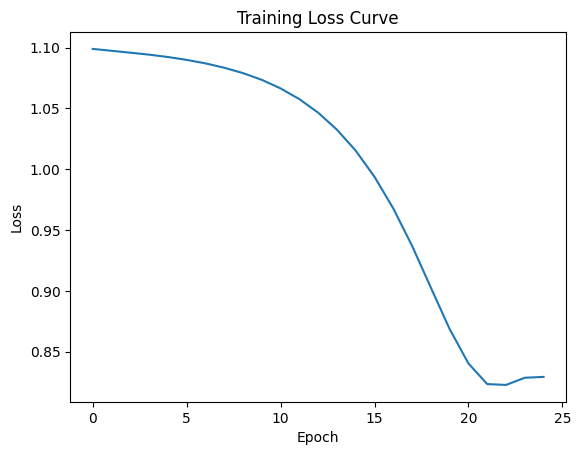


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2876
           1       0.32      0.10      0.15       606
           2       0.44      0.91      0.59       639

    accuracy                           0.71      4121
   macro avg       0.54      0.60      0.52      4121
weighted avg       0.72      0.71      0.69      4121



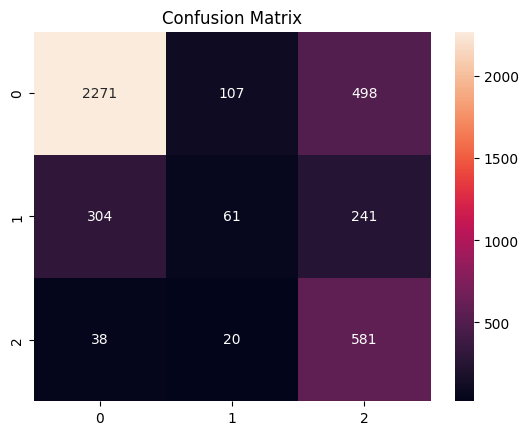

Accuracy: 0.7068672652268867
F1 Score: 0.6920541526196344


In [13]:
model = CNN_LSTM_Model(X_seq.shape[2], 128, 3)
model, losses = train_model(model)

# Loss curve
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Evaluate
acc, f1, probs = evaluate_model(model)

print("Accuracy:", acc)
print("F1 Score:", f1)

Feature Importance Analysis
`Random Forest Interpretability Analysis`

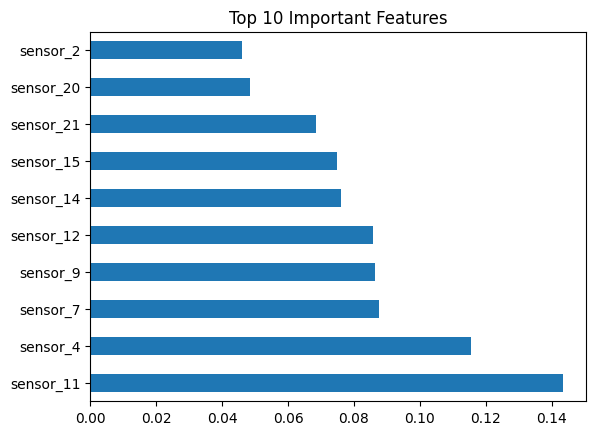

In [14]:
rf = RandomForestClassifier()
rf.fit(features, labels)

importances = rf.feature_importances_

feat_importance = pd.Series(importances, index=features.columns)
feat_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()